# Simulating CoreXY Dynamics
William Forcey

In our senior design project we are using a CoreXY mechanism driven by two stepper motors. The CoreXY mechanism converts the rotation of the stepper motors into linear movement of an end-effector in the x-y plane. It is desirable to simulate the motion of the system to estimate how long movements will take. Or in other words, when we can expect the end effector to reach a certain position or velocity. In simulating the CoreXY system we will use the approach taken in [1] where it is assumed the stepper motors can input any arbitrary angle into the mechanism. This input will be limited by our theoretical and experimental limits of stepper motor angular acceleration and velocity. After the input angle is known, we can simulate the dyanamics of the end-effector from the elastic belts, moving masses, and friction in the CoreXY system.

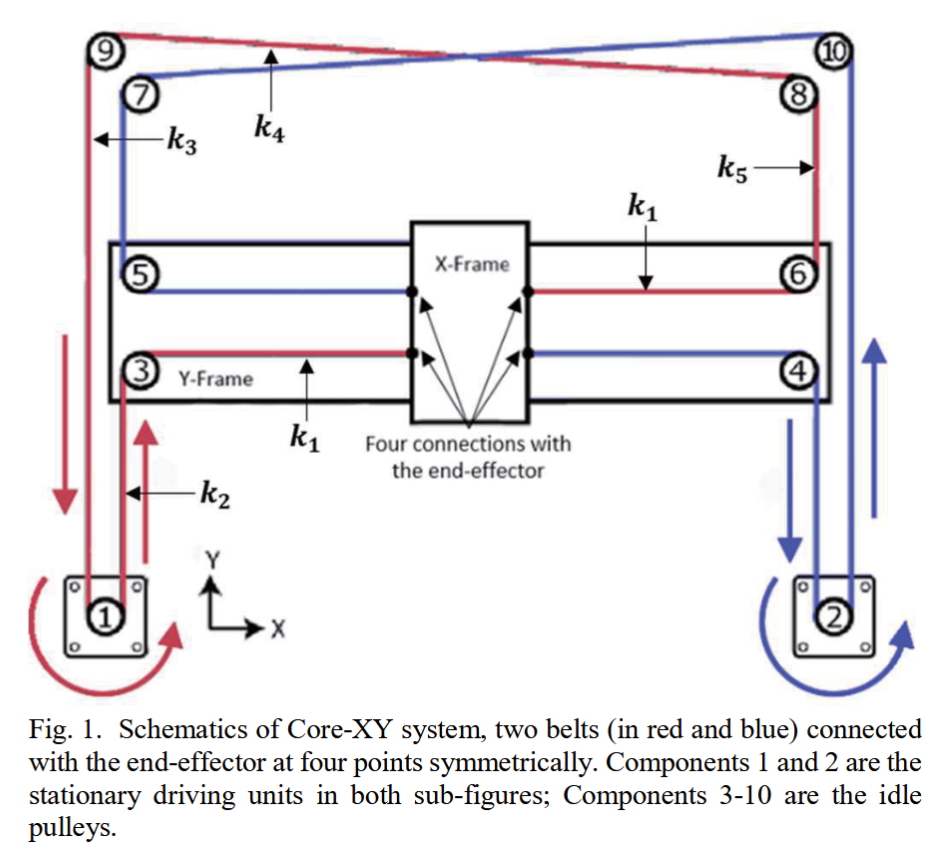

Our comparative CoreXY system for our senior design project air hockey robot
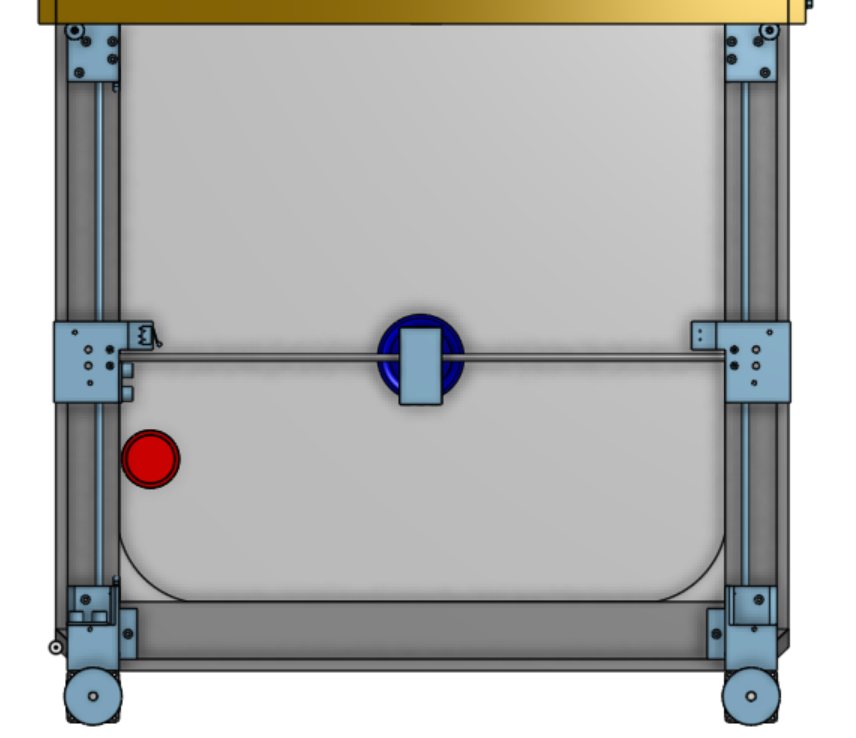

## Full DoF Model

The dynamics of the system are given in [1] as
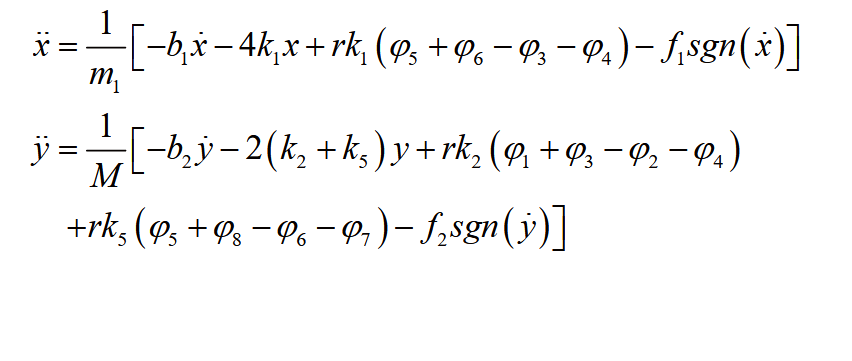

Where x and y are the cartesian coordinates of the end effector.
Angular acceleration of the pulleys is given in [1] as
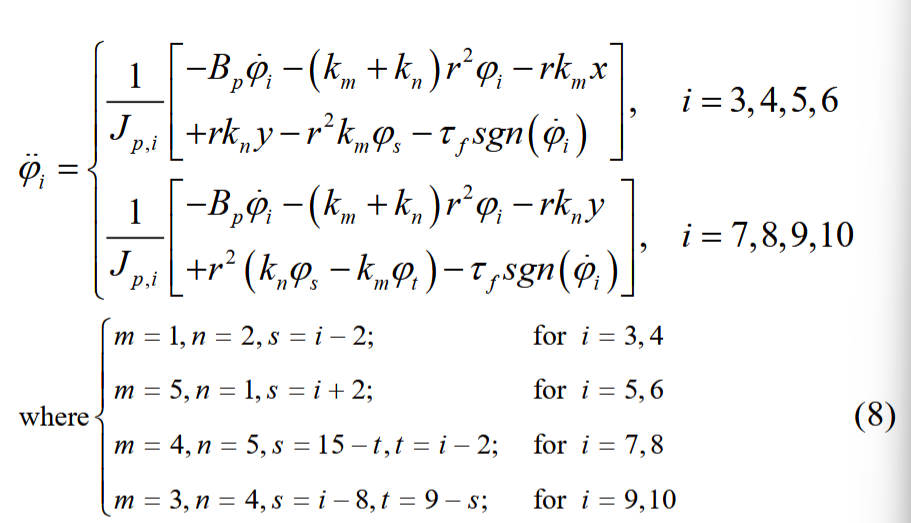

The final state space equation given in [1] is
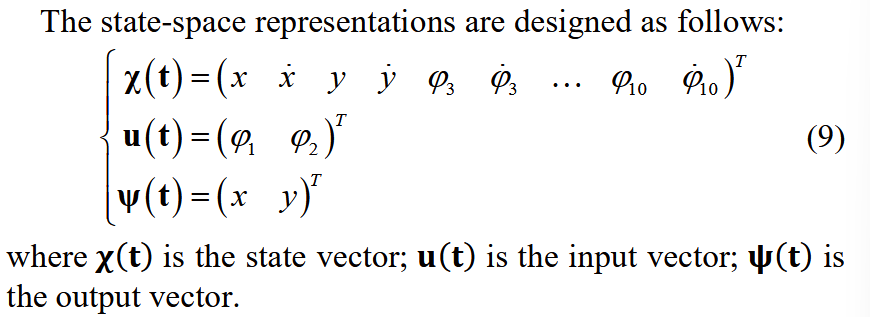

## 4-DoF Model
The paper [1] also gives a simplified 4-DoF model. This is a lower-order model. In the lower-order model the state vector only involves $x$ and $y$. The simplified model is given as

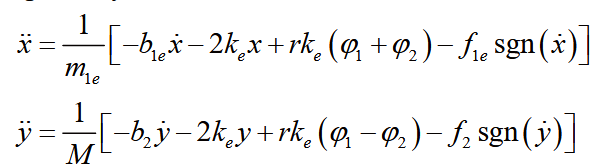

## Simplification for Simulation Stability Analysis
When talking with Dr. Adams, it was noted that the only non-linearity in the system is from the $sgn()$ Colulomb friction terms. If coefficients $f_1 = f_2 = \tau_f = 0$ then the system is linear. In this project these coefficients will be assumed to equal zero when performing eigenvalue analysis with simulation stability regions.

## Calculating CoreXY Constants

To find belt stiffness k we can use the equation given in [1] of 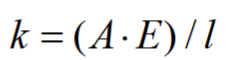

From [2] the Young's modulus of our belt (GT2 9mm, fiberglass reinforced, 5m long) is
$$ (593 * 0.35) - 0.1*(593 * 0.35) = 187 Mpa $$

This is taken from note 4 and 7 in [2] where the belt tensile modulus should be proportioned directly to the given value for a 1" width belt and reduced by 10%.

Cross-sectional area of belt is

$$ A = 0.001 * 0.009 = 9\times 10^{-6} [m] $$

Thus for our CoreXY gantry setup we have stiffness constants:
$$ k_1 = (A \times 187\times10^{6}) / (345\times10^{-3}) 
\\
k_2 = (A \times 187\times10^{6}) / (305\times10^{-3})
\\
k_3 = (A \times 187\times10^{6}) / (733\times10^{-3})
\\
k_4 = (A \times 187\times10^{6}) / (771\times10^{-3})
\\
k_5 \approx k_2
$$

For friction coeffcients we will assume ball bearing with lubrication viscous damping coefficient $C = 0.001$. Each ideler pulley has two ball bearings so:
$$ B_p = 0.001\times2 = 0.002$$

The Coulomb friction torque of one idler pulley will then be taken as $\mu = 0.002$ (common ball bearing coefficient found on google), $F_N = 20 [N]$ (a common value for 3D printer belt tension found on google), $r = 6\times10^{-3}$ (radius of the selected idler pulleys on our CoreXY gantry)

$$\tau_f = 2\times\mu F_N r = 480\times10^{-6} [N]$$

Viscous friction of the end-effector x-frame and y-frame is assumed to be very low, and mostly due to friction of the ball bearings used as guides to the end-effector motion. Thus the same coefficient $C = 0.001$ will be used for ball bearings normally in contact with a guide rails during motion. There are 3 ball bearings in contact with a guide rail for the x-frame and 8 for the y-frame.

$$ b_1 = 0.001 \times 3 = 0.003$$
$$ b_2 = 0.001 \times 8 = 0.008$$ 

The idler pulley moment of inertia can be approximated by finding the moment of inertia for an aluminum cylinder with a cylindrical hole through the middle. (https://byjus.com/jee/moment-of-inertia-of-a-hollow-cylinder/)

$$ J = 0.65\times 0.006^2 = 23.51\times10^{-6} [kg \cdot m^2]$$

The mass of the end effector (carriage plus mallet) is approximately

$$ m_1 = 0.1 [kg] $$

from assuming PLA density $1240 [kg/m^3]$.

The mass of the y-frame is approximately

$$ M = 0.5 [kg] $$

from steel density and PLA density multiplied by their respective volumes in the CoreXY construction.

Coulomb friction of the end-effector x-frame and y-frame is assumed to be very low, and again mostly due to friction of the ball bearings used as guides to the end-effector motion. Thus the same coefficient $\mu = 0.002$ will be used to approximate rolling friction of steel ball bearings normally in contact with steel guide rails during motion. There are 3 ball bearings in contact with a guide rail for the x-frame and 8 for the y-frame.

$$ f_1 = 0.002 \times 3 = 0.006$$
$$ f_2 = 0.002 \times 8 = 0.016$$

The idler pulleys used are all of diameter 12.1mm and radius 6.05mm. The drive pulleys for this senior design project are 28mm in radius. This radius was selected to provide for a higher top end effector speed at the selected stepper motor rated maximum rpm. r from [1] will be set to 6.05mm. The drive pulley radius will be used in calculating the input $\varphi_1$ and $\varphi_2$ versus each step. The stepper motors in this project are 200 steps per revoltion controlled at 1/8 microstepping giving an effective 1600 microsteps per revolution. Thus (assuming no slippage) one step of the drive pulley moves a section of belt of length:

$$ l = \Delta\varphi \cdot r_{drive} = \frac{2\pi}{1600} \times 0.028 = 0.00011 [m]$$

To move the same length of belt with a 6.05mm pulley would require it to spin

$$ \Delta\theta = \frac{l}{r_{idler}} = \frac{0.00011}{0.00605} = 0.0182 $$

So each time we want to simulate a step input to the CoreXY, a step input of angle 0.0182 will be used.



## System Setup and Parameters

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.backends.backend_pdf

pi = np.pi
i = 1j

# write function for Bresenham's as used in senior design project here
# input desired x, y and output each motor step period
def calculateStepPeriod(rpm):
    # microsteps/sec = (RPM / 60) * steps_per_rev
    microsteps_per_second = (rpm / 60.0) * 1600;
    return (1 / microsteps_per_second);

def calculateSteps(x, y):
    step_displacement_x = 1600/(2*pi*0.028) * x;
    step_displacement_y = 1600/(2*pi*0.028) * y;

    return (
        (step_displacement_x + step_displacement_y),
        (step_displacement_x - step_displacement_y)
    )

# all the way across table from bottom-left corner to top-right corner
targetX = 0.610
targetY = 0.533

rpm = 350

stepsA, stepsB = calculateSteps(targetX, targetY)  # input where you want to go
stepPeriod = calculateStepPeriod(rpm)        # input at what motor top speed
stepPeriodA = 0
stepPeriodB = 0

print(calculateSteps(targetX, targetY))
print(stepsA)
print(stepsB)

if (abs(stepsA) > abs(stepsB)):
    stepPeriodA = stepPeriod
    
    if (stepsB != 0):
        stepPeriodB = abs(stepsA/stepsB) * stepPeriod
    
    print("Need sim time at least: ")
    print(stepPeriod*abs(stepsA))
else:
    stepPeriodB = stepPeriod
    
    if (stepsA != 0):
        stepPeriodA = abs(stepsB/stepsA) * stepPeriod
    
    print("Need sim time at least: ")
    print(stepPeriod*abs(stepsB))
    
print(stepPeriodA)
print(stepPeriodB)

# CoreXY constants
m1 = 0.1
M = 0.5
r = 6.05e-3 # idler pulleys https://www.amazon.com/WINSINN-Aluminum-Timing-Toothless-Printer/dp/B07BPHRSN5/ref=pd_bxgy_d_sccl_2/145-3721308-2825215?pd_rd_w=miC0n&content-id=amzn1.sym.de9a1315-b9df-4c24-863c-7afcb2e4cc0a&pf_rd_p=de9a1315-b9df-4c24-863c-7afcb2e4cc0a&pf_rd_r=FK485B907XM0FMHZZ1K0&pd_rd_wg=ifQg6&pd_rd_r=4d322299-86fb-4e51-a004-3f776f17b554&pd_rd_i=B07BPHRSN5&th=1
r_drive = 28e-3 # our 3D printed 90T drive pulley radius
# f1 = 0.006 # Coulomb friction
# f2 = 0.016
f1 = 0 # Coulomb friction
f2 = 0
b1 = 0.003  # viscous damping
b2 = 0.008

# tau_f = 480e-6
tau_f = 0
Bp = 0.002

J = 23.51e-6  # idler pulley inertia

E = 187e6 # pascals
A = 1e-3 * 9e-3 # GT2 9mm belt cross sectional area
k1 = (A*E)/(345e-3)
k2 = (A*E)/(305e-3)
k3 = (A*E)/(733e-3)
k4 = (A*E)/(771e-3)
k5 = k2

(10395.091425944935, 700.281749604339)
10395.091425944935
700.281749604339
Need sim time at least: 
1.1137597956369574
0.00010714285714285715
0.0015904452690166987


## Detailed Stability Region for Forward-Euler-Backward-Euler
Modified from example by Dr. Adams. The eigenvalue $\lambda T$ products of the Full DoF model are shown on the stability region.

There are 20 eigenvalues.
eigenvalues: 
[-1.94581477e+05   +0.j         -8.40375675e+03+5141.07546278j
 -8.40375675e+03-5141.07546278j -2.13682479e+04   +0.j
 -1.37076535e+04   +0.j         -4.41442623e+04   +0.j
 -7.97871486e+03+4705.87347678j -7.97871486e+03-4705.87347678j
 -1.61858928e+04   +0.j         -1.91911350e+04   +0.j
  1.00000000e+00   +0.j          1.00000000e+00   +0.j
  1.00000000e+00   +0.j          1.00000000e+00   +0.j
  1.00000000e+00   +0.j          1.00000000e+00   +0.j
  1.00000000e+00   +0.j          1.00000000e+00   +0.j
  1.00000000e+00   +0.j          1.00000000e+00   +0.j        ]


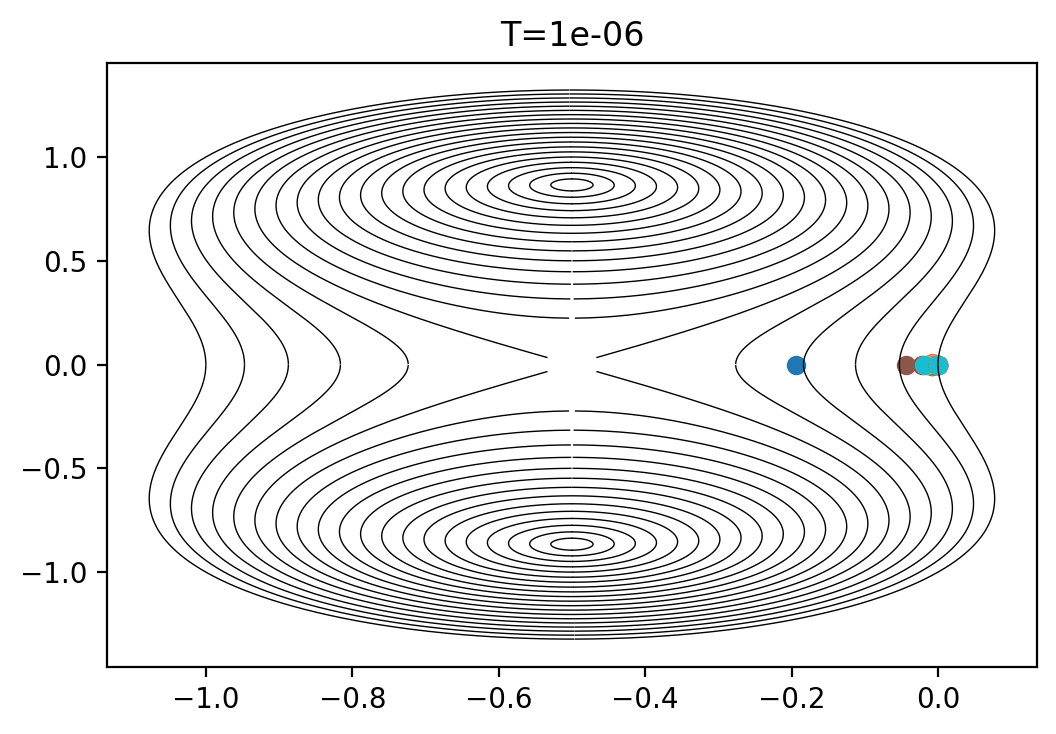

In [39]:
# Get eigenvalues of full DoF model with Coulomb friction
# coefficients set to zero

# order of states
# x, xf, y, yf, phi3, phi3f, ..., phi10, phi10f

A = np.array([
    [-4*k1/m1, -b1/m1, 0, 0, -r*k1/m1, 0, -r*k1/m1, 0, r*k1/m1, 0, r*k1/m1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, -2*(k2+k5)/M, -b2/M, r*k2/M, 0, -r*k2/M, 0, r*k5/M, 0, -r*k5/M , 0, -r*k5/M, 0, r*k5/M, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [-r*k1/J, 0, r*k2/J, 0, - (k1+k2)*(r**2)/J, -Bp/J, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [-r*k1/J, 0, r*k2/J, 0, 0, 0, - (k1+k2)*(r**2)/J, -Bp/J, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [- r*k5/J, 0, r*k1/J, 0, 0, 0, 0, 0, - (k5+k1)*(r**2)/J, -Bp/J, 0, 0, - r**2*k5/J, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [- r*k5/J, 0, r*k1/J, 0, 0, 0, 0, 0, 0, 0, - (k5+k1)*(r**2)/J, -Bp/J, 0, 0, - r**2*k5/J, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, - r*k5/J, 0, 0, 0, 0, 0, -k4*r**2/J, 0, 0, 0, - (k4+k5)*(r**2)/J, -Bp/J, 0, 0, 0, 0, r**2*k5/J, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, - r*k5/J, 0, 0, 0, 0, 0, 0, 0, -k4*r**2/J, 0, 0, 0, - (k4+k5)*(r**2)/J, -Bp/J, r**2*k5/J, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, - r*k4/J, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -k3*r**2/J, 0, - (k3+k4)*(r**2)/J, -Bp/J, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, - r*k4/J, 0, 0, 0, 0, 0, 0, 0, 0, 0, -k3*r**2/J, 0, 0, 0, 0, 0, - (k3+k4)*(r**2)/J, -Bp/J],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],  
])

# get the eigenvalues (system poles) and eigenvectors
l, _ = np.linalg.eig(A)

print(f"There are {len(l)} eigenvalues.")
print("eigenvalues: ")
print(l)

Nr = 20
dr = 1/Nr
rvec = np.zeros(Nr)
temp = np.arange(0,1+(dr/10),dr)
for k in range(0,Nr):
    rvec[k] = temp[Nr-k]
    
Ntheta = 1001
dtheta = 2*pi/(1*(Ntheta))
theta = np.arange(-pi+dtheta,pi+(dtheta/10),dtheta)
z = i*np.zeros(Ntheta) 
wp = i*np.zeros(Ntheta)
wn = i*np.zeros(Ntheta)

Nfirst = int((Ntheta-1)/2)

Nt = 61
dt = pi/Nt
tvec = np.arange(0,pi,dt)

Nrho = 1001
drho = (1-0)/(Nrho)
rho = np.zeros(Nrho)
temp =  np.arange(0,1+(drho/10),drho)
for k in range(0,Nrho):
    rho[k] = temp[Nrho-k]
 
    
wpr = i*np.zeros(Nrho)
wnr = i*np.zeros(Nrho)

plt.figure(dpi=200)
for k in range(0,Nr):
    z = rvec[k]*np.exp(i*theta)
        
    for m in range(0,Ntheta):
        wp[m] = (-1 + np.sqrt(4*z[m]-3))/2
        wn[m] = (-1 - np.sqrt(4*z[m]-3))/2
    
    wp[Ntheta-1] = wn[0]
    wn[Ntheta-1] = wp[0]
    
    
    plt.plot(np.real(wp[1:Nfirst]),np.imag(wp[1:Nfirst]),'k',linewidth=0.5)
    plt.plot(np.real(wp[Nfirst:Ntheta]),np.imag(wp[Nfirst:Ntheta]),'k',linewidth=0.5)
    plt.plot(np.real(wn[1:Nfirst]),np.imag(wn[1:Nfirst]),'k',linewidth=0.5)
    plt.plot(np.real(wn[Nfirst:Ntheta]),np.imag(wn[Nfirst:Ntheta]),'k',linewidth=0.5)

# add lambda-T products to the stability region
T = 0.000001
for k in range(0, len(l)):
    plt.scatter(np.real(l[k])*T,np.imag(l[k])*T)
    
plt.title(f"T={T}")
plt.show()

## Full DoF Model Simulation

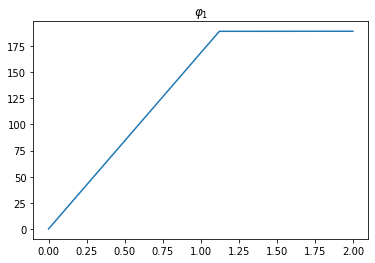

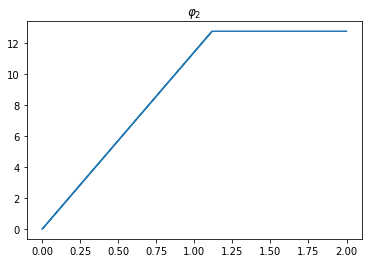

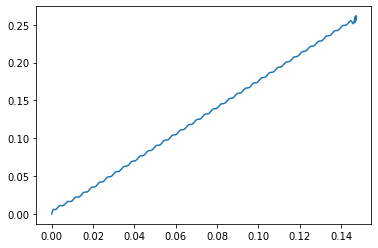

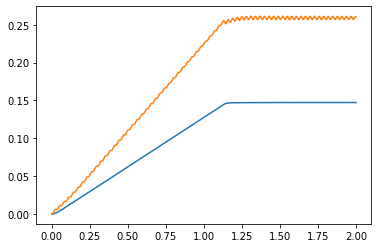

In [40]:
tfinal = 2  # final time in seconds

T = 0.000001

tvec = np.arange(-2*T, tfinal+(T/10), T)
N = tvec.shape[0]

# initialize system states and derivatives
x = np.zeros(N)  # x position
y = np.zeros(N)  # y position
xf = np.zeros(N)  # x velocity
yf = np.zeros(N)  # y velocity
xff = np.zeros(N)  # x acceleration
yff = np.zeros(N)  # y acceleration

phi = np.zeros((10,N)) # pulley angles
phif = np.zeros((10,N)) # pulley angular velocities
phiff = np.zeros((10,N)) # pulley angular acceleration

# set intial conditions if any
# I will just assume starting from rest (no intial velocity)
# x[0] = 0.25
# y[0] = 0.25

# get stepper input from Bresenham's controller like
# in our CoreXY control code
currentAngleA = 0
currentStepsA = 0
currentAngleB = 0
currentStepsB = 0
prevkT = 0
for k in range(0, N):    
    phi[0,k] = currentAngleA
    if (k*T - prevkT > stepPeriodA and currentStepsA < abs(stepsA)):
        phi[0,k] = currentAngleA+np.sign(stepsA)*0.0182
        prevkT = k*T
        currentStepsA += 1
        currentAngleA = phi[0,k]

prevkT = 0
for k in range(0, N):
    phi[1,k] = currentAngleB
    if (k*T - prevkT > stepPeriodB and currentStepsB < abs(stepsB)):
        phi[1,k] = currentAngleB+np.sign(stepsB)*0.0182
        prevkT = k*T
        currentStepsB += 1
        currentAngleB = phi[1,k]

# for k in range(5, N):
#     phi[0,k] = 0.0182

# simulate the system using Fwd-Euler - Bkwd-Euler Predictor-Corrector Pair
for k in range(0,N-1):
    # calculate derivatives
    xff[k] = 1/m1 * (-b1*xf[k] 
                       - 4*k1*x[k] 
                       + r*k1*(phi[4,k] + phi[5,k] - phi[2,k] - phi[3,k])
                       - f1*np.sign(xf[k])
                      )
    
    yff[k] = 1/M * (-b2*yf[k]
                      - 2*(k2+k5)*y[k]
                      + r*k2*(phi[0,k]+phi[2,k]-phi[1,k]-phi[3,k])
                      + r*k5*(phi[4,k]+phi[7,k]-phi[5,k]-phi[6,k])
                      - f2*np.sign(yf[k])
                     )
                      
    phiff[2,k] = 1/J * (-Bp*phif[2,k]
                        - (k1+k2)*(r**2)*phi[2,k]
                        - r*k1*x[k]
                        + r*k2*y[k]
                        - r**2*k1*phi[0,k]
                        - tau_f*np.sign(phif[2,k])
                       )
    
    phiff[3,k] = 1/J * (-Bp*phif[3,k]
                        - (k1+k2)*(r**2)*phi[3,k]
                        - r*k1*x[k]
                        + r*k2*y[k]
                        - r**2*k1*phi[1,k]
                        - tau_f*np.sign(phif[3,k])
                       )
    
    phiff[4,k] = 1/J * (-Bp*phif[4,k]
                        - (k5+k1)*(r**2)*phi[4,k]
                        - r*k5*x[k]
                        + r*k1*y[k]
                        - r**2*k5*phi[6,k]
                        - tau_f*np.sign(phif[4,k])
                       )
    
    phiff[5,k] = 1/J * (-Bp*phif[5,k]
                        - (k5+k1)*(r**2)*phi[5,k]
                        - r*k5*x[k]
                        + r*k1*y[k]
                        - r**2*k5*phi[7,k]
                        - tau_f*np.sign(phif[5,k])
                       )
    
    phiff[6,k] = 1/J * (-Bp*phif[6,k]
                        - (k4+k5)*(r**2)*phi[6,k]
                        - r*k5*y[k]
                        + r**2*(k5*phi[9,k]-k4*phi[4,k])
                        - tau_f*np.sign(phif[6,k])
                       )
    
    phiff[7,k] = 1/J * (-Bp*phif[7,k]
                        - (k4+k5)*(r**2)*phi[7,k]
                        - r*k5*y[k]
                        + r**2*(k5*phi[8,k]-k4*phi[5,k])
                        - tau_f*np.sign(phif[7,k])
                       )
    
    phiff[8,k] = 1/J * (-Bp*phif[8,k]
                        - (k3+k4)*(r**2)*phi[8,k]
                        - r*k4*y[k]
                        + r**2*(k4*phi[0,k]-k3*phi[7,k])
                        - tau_f*np.sign(phif[8,k])
                       )
    
    phiff[9,k] = 1/J * (-Bp*phif[9,k]
                        - (k3+k4)*(r**2)*phi[9,k]
                        - r*k4*y[k]
                        + r**2*(k4*phi[1,k]-k3*phi[6,k])
                        - tau_f*np.sign(phif[9,k])
                       )
    
    # prediction
    xfp = xf[k] + T*xff[k]
    xp = x[k] + T*xf[k]
    yfp = yf[k] + T*yff[k]
    yp = y[k] + T*yf[k]
    
    # only solve for idler pulleys, drive pulleys regarded as input
    phiffp = np.zeros(10)
    phifp = np.zeros(10)
    phip = np.zeros(10)
    
    phifp[2:] = phif[2:,k] + T*phiff[2:,k]
    phip[2:] = phi[2:,k] + T*phif[2:,k]
    
    # evaluatue (predict derivatives)
    xffp = 1/m1 * (-b1*xfp 
                       - 4*k1*xp 
                       + r*k1*(phip[4] + phip[5] - phip[2] - phip[3])
                       - f1*np.sign(xfp)
                      )
    
    yffp = 1/M * (-b2*yfp
                      - 2*(k2+k5)*yp
                      + r*k2*(phi[0,k+1]+phip[2]-phi[1,k+1]-phip[3])
                      + r*k5*(phip[4]+phip[7]-phip[5]-phip[6])
                      - f2*np.sign(yfp)
                     )
                      
    phiffp[2] = 1/J * (-Bp*phifp[2]
                        - (k1+k2)*(r**2)*phip[2]
                        - r*k1*xp
                        + r*k2*yp
                        - r**2*k1*phi[0,k+1]
                        - tau_f*np.sign(phifp[2])
                       )
    
    phiffp[3] = 1/J * (-Bp*phifp[3]
                        - (k1+k2)*(r**2)*phip[3]
                        - r*k1*xp
                        + r*k2*yp
                        - r**2*k1*phi[1,k+1]
                        - tau_f*np.sign(phifp[3])
                       )
    
    phiffp[4] = 1/J * (-Bp*phifp[4]
                        - (k5+k1)*(r**2)*phip[4]
                        - r*k5*xp
                        + r*k1*yp
                        - r**2*k5*phip[6]
                        - tau_f*np.sign(phifp[4])
                       )
    
    phiffp[5] = 1/J * (-Bp*phifp[5]
                        - (k5+k1)*(r**2)*phip[5]
                        - r*k5*xp
                        + r*k1*yp
                        - r**2*k5*phip[7]
                        - tau_f*np.sign(phifp[5])
                       )
    
    phiffp[6] = 1/J * (-Bp*phifp[6]
                        - (k4+k5)*(r**2)*phip[6]
                        - r*k5*yp
                        + r**2*(k5*phip[9]-k4*phip[4])
                        - tau_f*np.sign(phifp[6])
                       )
    
    phiffp[7] = 1/J * (-Bp*phifp[7]
                        - (k4+k5)*(r**2)*phip[7]
                        - r*k5*yp
                        + r**2*(k5*phip[8]-k4*phip[5])
                        - tau_f*np.sign(phifp[7])
                       )
    
    phiffp[8] = 1/J * (-Bp*phifp[8]
                        - (k3+k4)*(r**2)*phip[8]
                        - r*k4*yp
                        + r**2*(k4*phi[0,k+1]-k3*phip[7])
                        - tau_f*np.sign(phifp[8])
                       )
    
    phiffp[9] = 1/J * (-Bp*phifp[9]
                        - (k3+k4)*(r**2)*phip[9]
                        - r*k4*yp
                        + r**2*(k4*phi[1,k+1]-k3*phip[6])
                        - tau_f*np.sign(phifp[9])
                       )
    
    # corrector
    xf[k+1] = xf[k] + T*xffp
    x[k+1] = x[k] + T*xfp   
    yf[k+1] = yf[k] + T*yffp
    y[k+1] = y[k] + T*yfp
    
    # only solve for idler pulleys, drive pulleys regarded as input
    phif[2:,k+1] = phif[2:,k] + T*phiffp[2:]
    phi[2:,k+1] = phi[2:,k] + T*phifp[2:]   

# plot end-effector (CoreXY controlled mallet) paramterized over time
plt.plot(tvec,phi[0,:])
plt.title(fr"$\varphi_1$")
plt.show()

plt.plot(tvec,phi[1,:])
plt.title(fr"$\varphi_2$")
plt.show()

plt.plot(x[:],y[:])
plt.show()

plt.plot(tvec,x[:])

plt.plot(tvec,y[:])

# plt.axis([0,0.5,0,0.5])
# plt.scatter(f[0,:],f[1,:], s=0.01)
# plt.plot(f[0,:],f[1,:])

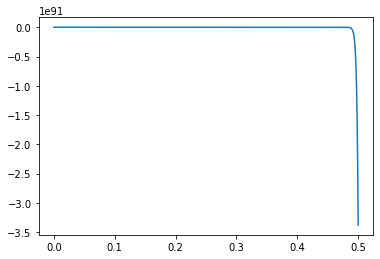

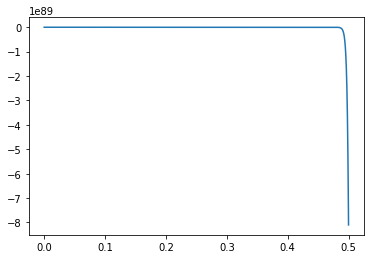

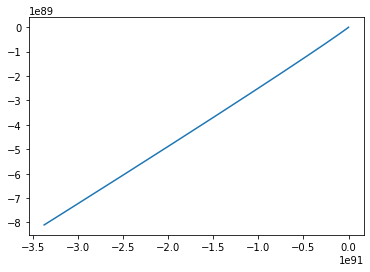

In [2]:
# Try simulating full system with AB2

tfinal = 0.5  # final time in seconds

T = 0.0000001

tvec = np.arange(-2*T, tfinal+(T/10), T)
N = tvec.shape[0]

# initialize system states and derivatives
x = np.zeros(N)  # x position
y = np.zeros(N)  # y position
xf = np.zeros(N)  # x velocity
yf = np.zeros(N)  # y velocity
xff = np.zeros(N)  # x acceleration
yff = np.zeros(N)  # y acceleration

phi = np.zeros((10,N)) # pulley angles
phif = np.zeros((10,N)) # pulley angular velocities
phiff = np.zeros((10,N)) # pulley angular acceleration

# set intial conditions if any
# I will just assume starting from rest (no intial velocity)
# x[0] = 0.25
# y[0] = 0.25

# get stepper input from Bresenham's controller like
# in our CoreXY control code
currentAngleA = 0
currentStepsA = 0
currentAngleB = 0
currentStepsB = 0
prevkT = 0
for k in range(0, N):    
    phi[0,k] = currentAngleA
    if (k*T - prevkT > stepPeriodA and currentStepsA < abs(stepsA)):
        phi[0,k] = currentAngleA+np.sign(stepsA)*0.0182
        prevkT = k*T
        currentStepsA += 1
        currentAngleA = phi[0,k]

prevkT = 0
for k in range(0, N):
    phi[1,k] = currentAngleB
    if (k*T - prevkT > stepPeriodB and currentStepsB < abs(stepsB)):
        phi[1,k] = currentAngleB+np.sign(stepsB)*0.0182
        prevkT = k*T
        currentStepsB += 1
        currentAngleB = phi[1,k]

# estimate one more set of initial conditions for 2nd explicit method
# calculate derivatives
xff[0] = 1/m1 * (-b1*xf[0] 
                   - 4*k1*x[0] 
                   + r*k1*(phi[4,0] + phi[5,0] - phi[2,0] - phi[3,0])
                   - f1*np.sign(xf[0])
                  )

yff[0] = 1/M * (-b2*yf[0]
                  - 2*(k2+k5)*y[0]
                  + r*k2*(phi[0,0]+phi[2,0]-phi[1,0]-phi[3,0])
                  + r*k5*(phi[4,0]+phi[7,0]-phi[5,0]-phi[6,0])
                  - f2*np.sign(yf[0])
                 )

phiff[2,0] = 1/J * (-Bp*phif[2,0]
                    - (k1+k2)*(r**2)*phi[2,0]
                    - r*k1*x[0]
                    + r*k2*y[0]
                    - r**2*k1*phi[0,0]
                    - tau_f*np.sign(phif[2,0])
                   )

phiff[3,0] = 1/J * (-Bp*phif[3,0]
                    - (k1+k2)*(r**2)*phi[3,0]
                    - r*k1*x[0]
                    + r*k2*y[0]
                    - r**2*k1*phi[1,0]
                    - tau_f*np.sign(phif[3,0])
                   )

phiff[4,0] = 1/J * (-Bp*phif[4,0]
                    - (k5+k1)*(r**2)*phi[4,0]
                    - r*k5*x[0]
                    + r*k1*y[0]
                    - r**2*k5*phi[6,0]
                    - tau_f*np.sign(phif[4,0])
                   )

phiff[5,0] = 1/J * (-Bp*phif[5,0]
                    - (k5+k1)*(r**2)*phi[5,0]
                    - r*k5*x[0]
                    + r*k1*y[0]
                    - r**2*k5*phi[7,0]
                    - tau_f*np.sign(phif[5,0])
                   )

phiff[6,0] = 1/J * (-Bp*phif[6,0]
                    - (k4+k5)*(r**2)*phi[6,0]
                    - r*k5*y[0]
                    + r**2*(k5*phi[9,0]-k4*phi[4,0])
                    - tau_f*np.sign(phif[6,0])
                   )

phiff[7,0] = 1/J * (-Bp*phif[7,0]
                    - (k4+k5)*(r**2)*phi[7,0]
                    - r*k5*y[0]
                    + r**2*(k5*phi[8,0]-k4*phi[5,0])
                    - tau_f*np.sign(phif[7,0])
                   )

phiff[8,0] = 1/J * (-Bp*phif[8,0]
                    - (k3+k4)*(r**2)*phi[8,0]
                    - r*k4*y[0]
                    + r**2*(k4*phi[0,0]-k3*phi[7,0])
                    - tau_f*np.sign(phif[8,0])
                   )

phiff[9,0] = 1/J * (-Bp*phif[9,0]
                    - (k3+k4)*(r**2)*phi[9,0]
                    - r*k4*y[0]
                    + r**2*(k4*phi[1,0]-k3*phi[6,0])
                    - tau_f*np.sign(phif[9,0])
                   )

# forward euler integrate to get next states as initial conditions for AB-2
# x[:,1] = x[:,0] + T*f[:,0]
xf[1] = xf[0] + T*xff[0]
x[1] = x[0] + T*xf[0]   
yf[1] = yf[9] + T*yff[0]
y[1] = y[9] + T*yf[0]

# only solve for idler pulleys, drive pulleys regarded as input
phif[2:,1] = phif[2:,0] + T*phiff[2:,0]
phi[2:,1] = phi[2:,0] + T*phif[2:,0]  

# simulate the system
# integrate using AB2
for k in range(0,N-2):
    # calculate derivatives
    xff[k] = 1/m1 * (-b1*xf[k] 
                       - 4*k1*x[k] 
                       + r*k1*(phi[4,k] + phi[5,k] - phi[2,k] - phi[3,k])
                       - f1*np.sign(xf[k])
                      )
    
    yff[k] = 1/M * (-b2*yf[k]
                      - 2*(k2+k5)*y[k]
                      + r*k2*(phi[0,k]+phi[2,k]-phi[1,k]-phi[3,k])
                      + r*k5*(phi[4,k]+phi[7,k]-phi[5,k]-phi[6,k])
                      - f2*np.sign(yf[k])
                     )
                      
    phiff[2,k] = 1/J * (-Bp*phif[2,k]
                        - (k1+k2)*(r**2)*phi[2,k]
                        - r*k1*x[k]
                        + r*k2*y[k]
                        - r**2*k1*phi[0,k]
                        - tau_f*np.sign(phif[2,k])
                       )
    
    phiff[3,k] = 1/J * (-Bp*phif[3,k]
                        - (k1+k2)*(r**2)*phi[3,k]
                        - r*k1*x[k]
                        + r*k2*y[k]
                        - r**2*k1*phi[1,k]
                        - tau_f*np.sign(phif[3,k])
                       )
    
    phiff[4,k] = 1/J * (-Bp*phif[4,k]
                        - (k5+k1)*(r**2)*phi[4,k]
                        - r*k5*x[k]
                        + r*k1*y[k]
                        - r**2*k5*phi[6,k]
                        - tau_f*np.sign(phif[4,k])
                       )
    
    phiff[5,k] = 1/J * (-Bp*phif[5,k]
                        - (k5+k1)*(r**2)*phi[5,k]
                        - r*k5*x[k]
                        + r*k1*y[k]
                        - r**2*k5*phi[7,k]
                        - tau_f*np.sign(phif[5,k])
                       )
    
    phiff[6,k] = 1/J * (-Bp*phif[6,k]
                        - (k4+k5)*(r**2)*phi[6,k]
                        - r*k5*y[k]
                        + r**2*(k5*phi[9,k]-k4*phi[4,k])
                        - tau_f*np.sign(phif[6,k])
                       )
    
    phiff[7,k] = 1/J * (-Bp*phif[7,k]
                        - (k4+k5)*(r**2)*phi[7,k]
                        - r*k5*y[k]
                        + r**2*(k5*phi[8,k]-k4*phi[5,k])
                        - tau_f*np.sign(phif[7,k])
                       )
    
    phiff[8,k] = 1/J * (-Bp*phif[8,k]
                        - (k3+k4)*(r**2)*phi[8,k]
                        - r*k4*y[k]
                        + r**2*(k4*phi[0,k]-k3*phi[7,k])
                        - tau_f*np.sign(phif[8,k])
                       )
    
    phiff[9,k] = 1/J * (-Bp*phif[9,k]
                        - (k3+k4)*(r**2)*phi[9,k]
                        - r*k4*y[k]
                        + r**2*(k4*phi[1,k]-k3*phi[6,k])
                        - tau_f*np.sign(phif[9,k])
                       )
    
    # integrate
#     x[:,k+2] = x[:,k+1] + (3*T/2)*f[:,k+1] - (T/2)*f[:,k]
    xf[k+2] = xf[k+1] + (3*T/2)*xff[k+1] - (T/2)*xff[k]
    x[k+2] = x[k+1] + (3*T/2)*xf[k+1] - (T/2)*xf[k]
    yf[k+2] = yf[k+1] + (3*T/2)*yff[k+1] - (T/2)*yff[k]
    y[k+2] = y[k+1] + (3*T/2)*yf[k+1] - (T/2)*yf[k]   
    
    xf[1] = xf[0] + T*xff[0]
    x[1] = x[0] + T*xf[0]   
    yf[1] = yf[9] + T*yff[0]
    y[1] = y[9] + T*yf[0]

    # only solve for idler pulleys, drive pulleys regarded as input
    phif[2:,k+2] = phif[2:,k+1] + (3*T/2)*phiff[2:,k+1] - (T/2)*phiff[2:,k]
    phi[2:,k+2] = phi[2:,k+1] + (3*T/2)*phif[2:,k+1] - (T/2)*phif[2:,k]
    
plt.plot(tvec,x[:])
plt.show()
plt.plot(tvec,y[:])
plt.show()
plt.plot(x[:],y[:])

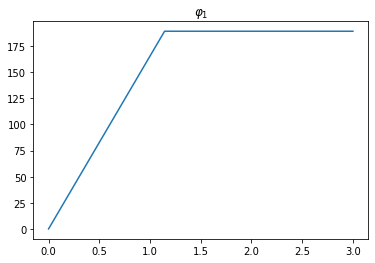

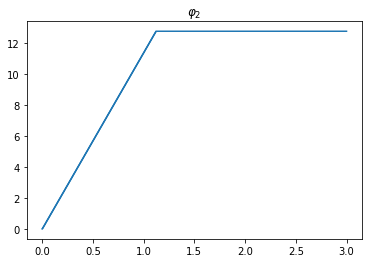

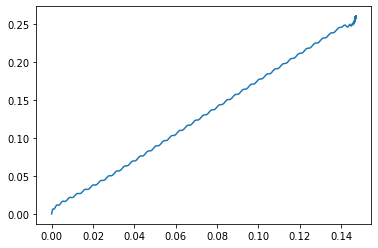

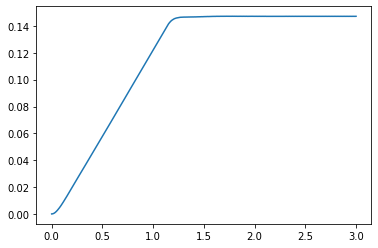

In [5]:
# Try simulating full system with Forward-Euler-Tustin

tfinal = 3  # final time in seconds

T = 0.00001

tvec = np.arange(-2*T, tfinal+(T/10), T)
N = tvec.shape[0]

# initialize system states and derivatives
x = np.zeros(N)  # x position
y = np.zeros(N)  # y position
xf = np.zeros(N)  # x velocity
yf = np.zeros(N)  # y velocity
xff = np.zeros(N)  # x acceleration
yff = np.zeros(N)  # y acceleration

phi = np.zeros((10,N)) # pulley angles
phif = np.zeros((10,N)) # pulley angular velocities
phiff = np.zeros((10,N)) # pulley angular acceleration

# set intial conditions if any
# I will just assume starting from rest (no intial velocity)
# x[0] = 0.25
# y[0] = 0.25

# get stepper input from Bresenham's controller like
# in our CoreXY control code
currentAngleA = 0
currentStepsA = 0
currentAngleB = 0
currentStepsB = 0
prevkT = 0
for k in range(0, N):    
    phi[0,k] = currentAngleA
    if (k*T - prevkT > stepPeriodA and currentStepsA < abs(stepsA)):
        phi[0,k] = currentAngleA+np.sign(stepsA)*0.0182
        prevkT = k*T
        currentStepsA += 1
        currentAngleA = phi[0,k]

prevkT = 0
for k in range(0, N):
    phi[1,k] = currentAngleB
    if (k*T - prevkT > stepPeriodB and currentStepsB < abs(stepsB)):
        phi[1,k] = currentAngleB+np.sign(stepsB)*0.0182
        prevkT = k*T
        currentStepsB += 1
        currentAngleB = phi[1,k]

# integrate using Fwd-Euler-Tustin predictor corrector pair
for k in range(0,N-1):
    # calculate derivatives
    xff[k] = 1/m1 * (-b1*xf[k] 
                       - 4*k1*x[k] 
                       + r*k1*(phi[4,k] + phi[5,k] - phi[2,k] - phi[3,k])
                       - f1*np.sign(xf[k])
                      )
    
    yff[k] = 1/M * (-b2*yf[k]
                      - 2*(k2+k5)*y[k]
                      + r*k2*(phi[0,k]+phi[2,k]-phi[1,k]-phi[3,k])
                      + r*k5*(phi[4,k]+phi[7,k]-phi[5,k]-phi[6,k])
                      - f2*np.sign(yf[k])
                     )
                      
    phiff[2,k] = 1/J * (-Bp*phif[2,k]
                        - (k1+k2)*(r**2)*phi[2,k]
                        - r*k1*x[k]
                        + r*k2*y[k]
                        - r**2*k1*phi[0,k]
                        - tau_f*np.sign(phif[2,k])
                       )
    
    phiff[3,k] = 1/J * (-Bp*phif[3,k]
                        - (k1+k2)*(r**2)*phi[3,k]
                        - r*k1*x[k]
                        + r*k2*y[k]
                        - r**2*k1*phi[1,k]
                        - tau_f*np.sign(phif[3,k])
                       )
    
    phiff[4,k] = 1/J * (-Bp*phif[4,k]
                        - (k5+k1)*(r**2)*phi[4,k]
                        - r*k5*x[k]
                        + r*k1*y[k]
                        - r**2*k5*phi[6,k]
                        - tau_f*np.sign(phif[4,k])
                       )
    
    phiff[5,k] = 1/J * (-Bp*phif[5,k]
                        - (k5+k1)*(r**2)*phi[5,k]
                        - r*k5*x[k]
                        + r*k1*y[k]
                        - r**2*k5*phi[7,k]
                        - tau_f*np.sign(phif[5,k])
                       )
    
    phiff[6,k] = 1/J * (-Bp*phif[6,k]
                        - (k4+k5)*(r**2)*phi[6,k]
                        - r*k5*y[k]
                        + r**2*(k5*phi[9,k]-k4*phi[4,k])
                        - tau_f*np.sign(phif[6,k])
                       )
    
    phiff[7,k] = 1/J * (-Bp*phif[7,k]
                        - (k4+k5)*(r**2)*phi[7,k]
                        - r*k5*y[k]
                        + r**2*(k5*phi[8,k]-k4*phi[5,k])
                        - tau_f*np.sign(phif[7,k])
                       )
    
    phiff[8,k] = 1/J * (-Bp*phif[8,k]
                        - (k3+k4)*(r**2)*phi[8,k]
                        - r*k4*y[k]
                        + r**2*(k4*phi[0,k]-k3*phi[7,k])
                        - tau_f*np.sign(phif[8,k])
                       )
    
    phiff[9,k] = 1/J * (-Bp*phif[9,k]
                        - (k3+k4)*(r**2)*phi[9,k]
                        - r*k4*y[k]
                        + r**2*(k4*phi[1,k]-k3*phi[6,k])
                        - tau_f*np.sign(phif[9,k])
                       )
    
    # prediction
    xfp = xf[k] + T*xff[k]
    xp = x[k] + T*xf[k]
    yfp = yf[k] + T*yff[k]
    yp = y[k] + T*yf[k]
    
    # only solve for idler pulleys, drive pulleys regarded as input
    phiffp = np.zeros(10)
    phifp = np.zeros(10)
    phip = np.zeros(10)
    
    phifp[2:] = phif[2:,k] + T*phiff[2:,k]
    phip[2:] = phi[2:,k] + T*phif[2:,k]
    
    # evaluatue (predict derivatives)
    xffp = 1/m1 * (-b1*xfp 
                       - 4*k1*xp 
                       + r*k1*(phip[4] + phip[5] - phip[2] - phip[3])
                       - f1*np.sign(xfp)
                      )
    
    yffp = 1/M * (-b2*yfp
                      - 2*(k2+k5)*yp
                      + r*k2*(phi[0,k]+phip[2]-phi[1,k]-phip[3])
                      + r*k5*(phip[4]+phip[7]-phip[5]-phip[6])
                      - f2*np.sign(yfp)
                     )
                      
    phiffp[2] = 1/J * (-Bp*phifp[2]
                        - (k1+k2)*(r**2)*phip[2]
                        - r*k1*xp
                        + r*k2*yp
                        - r**2*k1*phi[0,k]
                        - tau_f*np.sign(phifp[2])
                       )
    
    phiffp[3] = 1/J * (-Bp*phifp[3]
                        - (k1+k2)*(r**2)*phip[3]
                        - r*k1*xp
                        + r*k2*yp
                        - r**2*k1*phi[1,k]
                        - tau_f*np.sign(phifp[3])
                       )
    
    phiffp[4] = 1/J * (-Bp*phifp[4]
                        - (k5+k1)*(r**2)*phip[4]
                        - r*k5*xp
                        + r*k1*yp
                        - r**2*k5*phip[6]
                        - tau_f*np.sign(phifp[4])
                       )
    
    phiffp[5] = 1/J * (-Bp*phifp[5]
                        - (k5+k1)*(r**2)*phip[5]
                        - r*k5*xp
                        + r*k1*yp
                        - r**2*k5*phip[7]
                        - tau_f*np.sign(phifp[5])
                       )
    
    phiffp[6] = 1/J * (-Bp*phifp[6]
                        - (k4+k5)*(r**2)*phip[6]
                        - r*k5*yp
                        + r**2*(k5*phip[9]-k4*phip[4])
                        - tau_f*np.sign(phifp[6])
                       )
    
    phiffp[7] = 1/J * (-Bp*phifp[7]
                        - (k4+k5)*(r**2)*phip[7]
                        - r*k5*yp
                        + r**2*(k5*phip[8]-k4*phip[5])
                        - tau_f*np.sign(phifp[7])
                       )
    
    phiffp[8] = 1/J * (-Bp*phifp[8]
                        - (k3+k4)*(r**2)*phip[8]
                        - r*k4*yp
                        + r**2*(k4*phi[0,k]-k3*phip[7])
                        - tau_f*np.sign(phifp[8])
                       )
    
    phiffp[9] = 1/J * (-Bp*phifp[9]
                        - (k3+k4)*(r**2)*phip[9]
                        - r*k4*yp
                        + r**2*(k4*phi[1,k]-k3*phip[6])
                        - tau_f*np.sign(phifp[9])
                       )
    
    # corrector
    xf[k+1] = xf[k] + T/2*xffp + T/2*xff[k]
    x[k+1] = x[k] + T/2*xfp + T/2*xf[k]   
    yf[k+1] = yf[k] + T/2*yffp + T/2*yff[k]
    y[k+1] = y[k] + T/2*yfp + T/2*yf[k]
    
    # only solve for idler pulleys, drive pulleys regarded as input
    phif[2:,k+1] = phif[2:,k] + T/2*phiffp[2:] + T/2*phiff[2:,k]
    phi[2:,k+1] = phi[2:,k] + T/2*phifp[2:] + T/2*phif[2:,k]

# plot end-effector (CoreXY controlled mallet) paramterized over time
plt.plot(tvec,phi[0,:])
plt.title(fr"$\varphi_1$")
plt.show()

plt.plot(tvec,phi[1,:])
plt.title(fr"$\varphi_2$")
plt.show()

plt.plot(x[:],y[:])
plt.show()

plt.plot(tvec,x[:])

## Simplified 4-DoF Dynamic Modeling
The simplified 4-Dof model is derived in section D. of [1]. 

## 4-DoF Parameters

In [4]:
m1e = m1 + (4*J) / (r**2)
J1e = 3*J
J2e = 3*J

ke = (k1*k2) / (k1+k2) + (k1*k3*k4*k5) / (k1*k3*k4 + k1*k3*k5 + k1*k4*k5 + k3*k4*k5)

b1e = b1 + 4*Bp/(r**2)

f1e = f1 + 4*Bp/r

Bpe = 3*Bp

tau_fe = 3*tau_f

## Detailed Stability Region for Forward-Euler-Backward-Euler
Modified from example by Dr. Adams. The eigenvalue $\lambda T$ products of the 4-DoF model are shown on the stability region.

There are 4 eigenvalues.
eigenvalues: 
[-2.52550446e+03  1.00000000e+00 -1.34822713e+04  1.00000000e+00]


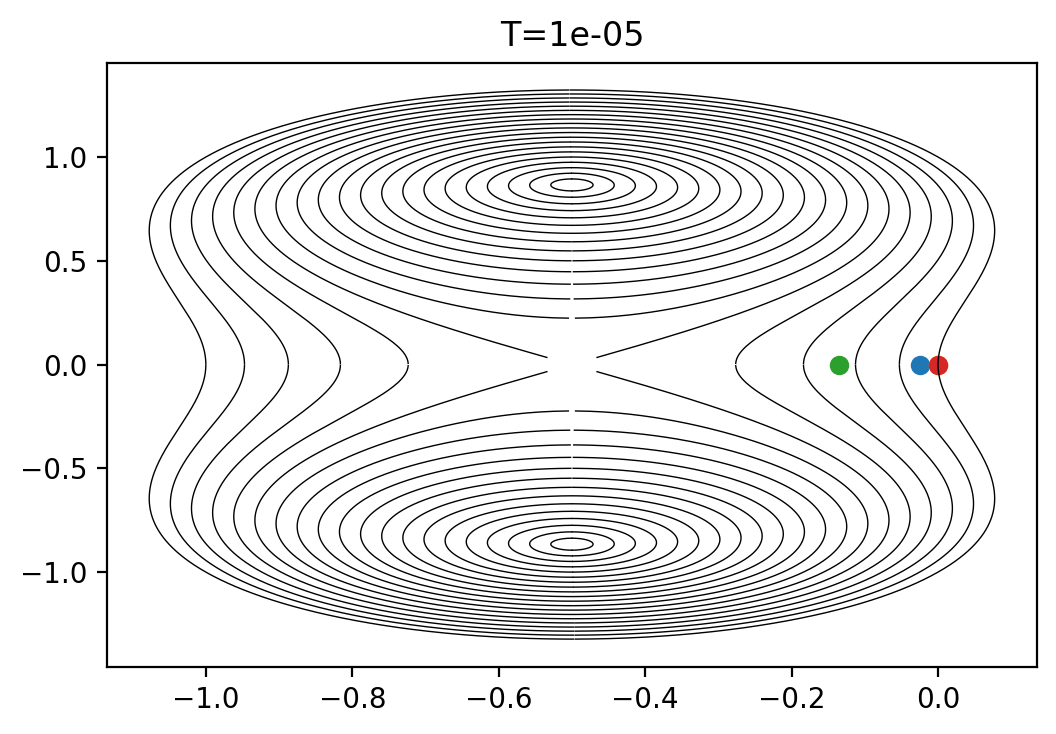

In [5]:
# Get eigenvalues of 4-DoF model with Coulomb friction
# coefficients set to zero

# order of states
# x, xf, y, yf

A = np.array([
    [-2*ke/m1e, -b1e/m1e, 0, 0],
    [0, 1, 0, 0],
    [0, 0, -2*ke/M, -b2/M],
    [0, 0, 0, 1],
])

# get the eigenvalues (system poles) and eigenvectors
l, _ = np.linalg.eig(A)

print(f"There are {len(l)} eigenvalues.")
print("eigenvalues: ")
print(l)

Nr = 20
dr = 1/Nr
rvec = np.zeros(Nr)
temp = np.arange(0,1+(dr/10),dr)
for k in range(0,Nr):
    rvec[k] = temp[Nr-k]
    
Ntheta = 1001
dtheta = 2*pi/(1*(Ntheta))
theta = np.arange(-pi+dtheta,pi+(dtheta/10),dtheta)
z = i*np.zeros(Ntheta) 
wp = i*np.zeros(Ntheta)
wn = i*np.zeros(Ntheta)

Nfirst = int((Ntheta-1)/2)

Nt = 61
dt = pi/Nt
tvec = np.arange(0,pi,dt)

Nrho = 1001
drho = (1-0)/(Nrho)
rho = np.zeros(Nrho)
temp =  np.arange(0,1+(drho/10),drho)
for k in range(0,Nrho):
    rho[k] = temp[Nrho-k]
 
    
wpr = i*np.zeros(Nrho)
wnr = i*np.zeros(Nrho)

plt.figure(dpi=200)
for k in range(0,Nr):
    z = rvec[k]*np.exp(i*theta)
        
    for m in range(0,Ntheta):
        wp[m] = (-1 + np.sqrt(4*z[m]-3))/2
        wn[m] = (-1 - np.sqrt(4*z[m]-3))/2
    
    wp[Ntheta-1] = wn[0]
    wn[Ntheta-1] = wp[0]
    
    
    plt.plot(np.real(wp[1:Nfirst]),np.imag(wp[1:Nfirst]),'k',linewidth=0.5)
    plt.plot(np.real(wp[Nfirst:Ntheta]),np.imag(wp[Nfirst:Ntheta]),'k',linewidth=0.5)
    plt.plot(np.real(wn[1:Nfirst]),np.imag(wn[1:Nfirst]),'k',linewidth=0.5)
    plt.plot(np.real(wn[Nfirst:Ntheta]),np.imag(wn[Nfirst:Ntheta]),'k',linewidth=0.5)

# add lambda-T products to the stability region
T = 0.00001
for k in range(0, len(l)):
    plt.scatter(np.real(l[k])*T,np.imag(l[k])*T)
    
plt.title(f"T={T}")
plt.show()

## 4-DoF Model Simulation

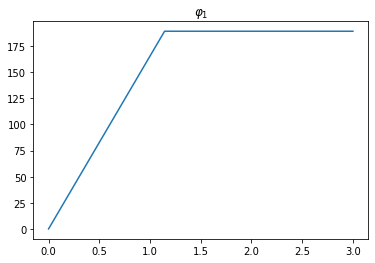

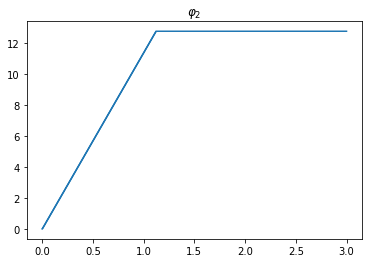

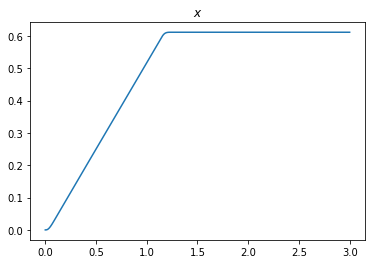

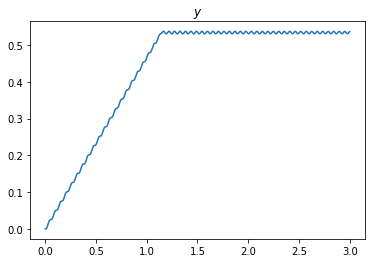

(-0.0635, 0.6731, -0.06985, 0.60325)

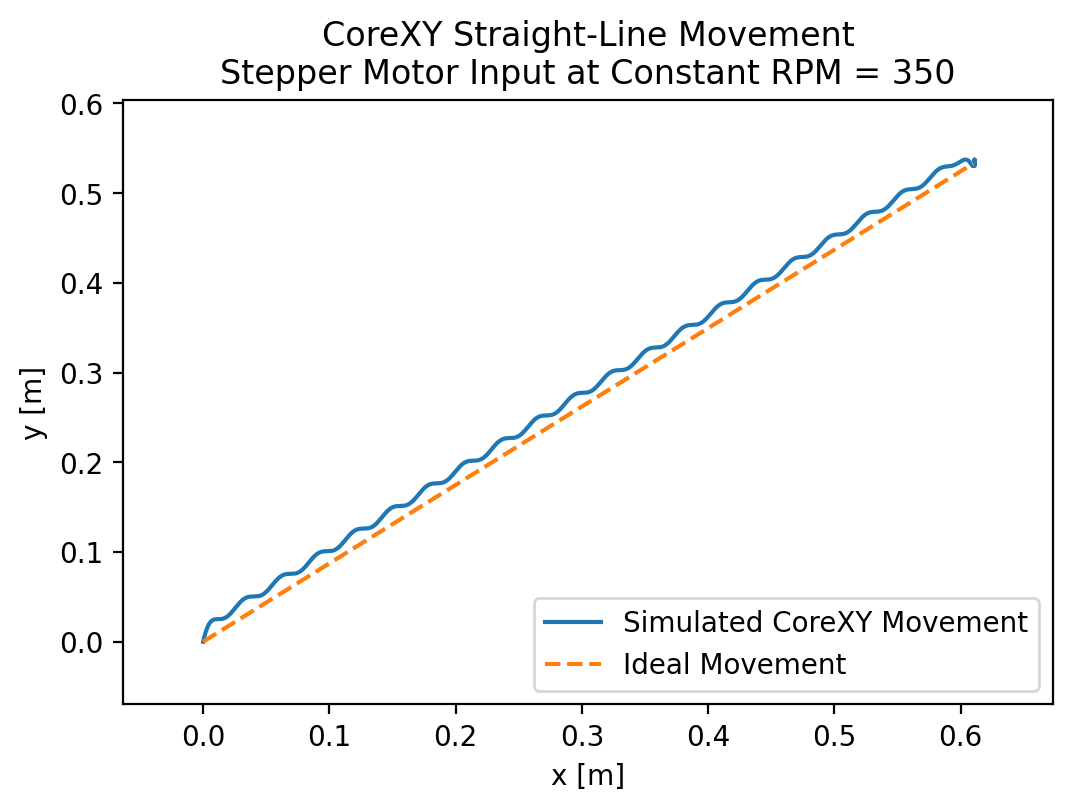

In [7]:
tfinal = 3  # final time in seconds

T = 0.00001

tvec = np.arange(-2*T, tfinal+(T/10), T)
N = tvec.shape[0]

# initialize system states and derivatives
x = np.zeros(N)  # x position
y = np.zeros(N)  # y position
xf = np.zeros(N)  # x velocity
yf = np.zeros(N)  # y velocity
xff = np.zeros(N)  # x acceleration
yff = np.zeros(N)  # y acceleration

# input drive pulley angles
phi = np.zeros((2,N))

# set intial conditions if any
# I will just assume starting from rest (no intial velocity)
x[0] = 0
y[0] = 0

# get stepper input from Bresenham's controller like
# in our CoreXY control code
currentAngleA = 0
currentStepsA = 0
currentAngleB = 0
currentStepsB = 0
prevkT = 0
for k in range(0, N):    
    phi[0,k] = currentAngleA
    if (k*T - prevkT > stepPeriodA and currentStepsA < abs(stepsA)):
        phi[0,k] = currentAngleA+np.sign(stepsA)*0.0182
        prevkT = k*T
        currentStepsA += 1
        currentAngleA = phi[0,k]

prevkT = 0
for k in range(0, N):
    phi[1,k] = currentAngleB
    if (k*T - prevkT > stepPeriodB and currentStepsB < abs(stepsB)):
        phi[1,k] = currentAngleB+np.sign(stepsB)*0.0182
        prevkT = k*T
        currentStepsB += 1
        currentAngleB = phi[1,k]

# simulate the system
# integrate using Fwd-Euler-Bkwd-Euler predictor corrector pair
# using similar pattern as shown in textbook Hartley, Beale, Chicatelli, example 4.16
for k in range(0,N-1):
    # calculate derivatives
    xff[k] = 1/m1e * (-b1e*xf[k]
                      - 2*ke*x[k]
                      + r*ke*(phi[0,k] + phi[1,k])
                      - f1e*np.sign(xf[k])
                     )
    
    yff[k] = 1/M * (-b2*yf[k]
                 - 2*ke*y[k]
                 + r*ke*(phi[0,k] - phi[1,k])
                 - f2*np.sign(yf[k])
                )

    # prediction
    xfp = xf[k] + T*xff[k]
    xp = x[k] + T*xf[k]
    yfp = yf[k] + T*yff[k]
    yp = y[k] + T*yf[k]
    
    # evaluatue (predict derivatives)
    xffp = 1/m1e * (-b1e*xfp
                      - 2*ke*xp
                      + r*ke*(phi[0,k+1] + phi[1,k+1])
                      - f1e*np.sign(xfp)
                     )
    
    yffp = 1/M * (-b2*yfp
                 - 2*ke*yp
                 + r*ke*(phi[0,k+1] - phi[1,k+1])
                 - f2*np.sign(yfp)
                )
    
    # corrector
    xf[k+1] = xf[k] + T*xffp
    x[k+1] = x[k] + T*xfp
    yf[k+1] = yf[k] + T*yffp
    y[k+1] = y[k] + T*yfp   
    
# plot end-effector (CoreXY controlled mallet) paramterized over time
plt.plot(tvec,phi[0,:])
plt.title(fr"$\varphi_1$")
plt.show()

plt.plot(tvec,phi[1,:])
plt.title(fr"$\varphi_2$")
plt.show()

plt.plot(tvec,x[:])
plt.title(fr"$x$")
plt.show()

plt.plot(tvec,y[:])
plt.title(fr"$y$")
plt.show()

plt.figure(dpi=200)
plt.plot(x[:],y[:], label=fr"Simulated CoreXY Movement")
plt.plot([0, targetX], [0, targetY], "--", label=fr"Ideal Movement")
plt.title(fr"CoreXY Straight-Line Movement" + "\n" + fr"Stepper Motor Input at Constant RPM = {rpm}")
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.legend(loc='lower right')

# axis bounds based on the physically implementd CoreXY gantry
# only some of the movement plane is accessible as the mallet radius is 0.05 [m]
plt.axis([-0.0635,0.6731,-0.06985,0.60325])

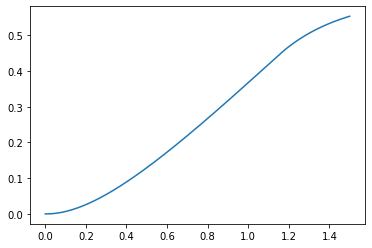

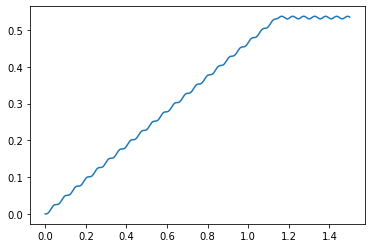

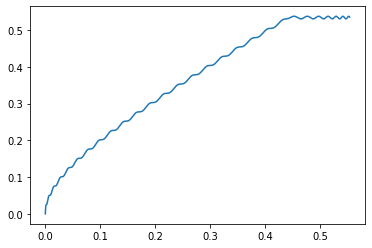

In [21]:
m1e = m1 + (4*J) / (r**2)
J1e = 3*J
J2e = 3*J

ke = (k1*k2) / (k1+k2) + (k1*k3*k4*k5) / (k1*k3*k4 + k1*k3*k5 + k1*k4*k5 + k3*k4*k5)

b1e = b1 + 4*Bp/(r**2)

f1e = f1 + 4*Bp/r

Bpe = 3*Bp

tau_fe = 3*tau_f

# states
tfinal = 1.5  # final time in seconds

T = 0.00001

tvec = np.arange(-2*T, tfinal+(T/10), T)
N = tvec.shape[0]

# initialize system states and derivatives
x = np.zeros(N)  # x position
y = np.zeros(N)  # y position
xf = np.zeros(N)  # x velocity
yf = np.zeros(N)  # y velocity
xff = np.zeros(N)  # x acceleration
yff = np.zeros(N)  # y acceleration

# input drive pulley angles
phi = np.zeros((2,N))

# set intial conditions if any
# I will just assume starting from rest (no intial velocity)
x[0] = 0
y[0] = 0

# get stepper input from Bresenham's controller like
# in our CoreXY control code
currentAngleA = 0
currentStepsA = 0
currentAngleB = 0
currentStepsB = 0
prevkT = 0
for k in range(0, N):    
    phi[0,k] = currentAngleA
    if (k*T - prevkT > stepPeriodA and currentStepsA < abs(stepsA)):
        phi[0,k] = currentAngleA+np.sign(stepsA)*0.0182
        prevkT = k*T
        currentStepsA += 1
        currentAngleA = phi[0,k]

prevkT = 0
for k in range(0, N):
    phi[1,k] = currentAngleB
    if (k*T - prevkT > stepPeriodB and currentStepsB < abs(stepsB)):
        phi[1,k] = currentAngleB+np.sign(stepsB)*0.0182
        prevkT = k*T
        currentStepsB += 1
        currentAngleB = phi[1,k]
        
# estimate one more set of intitial conditions for 2nd order explicit method
# f[:,0] = np.matmul(A,x[:,0]) + B.T*u[0]
xff[0] = 1/m1e * (-b1e*xf[0]
                      - 2*ke*x[0]
                      + r*ke*(phi[0,0] + phi[1,0])
                      - f1e*np.sign(xf[0])
                     )
    
yff[0] = 1/M * (-b2*yf[0]
             - 2*ke*y[0]
             + r*ke*(phi[0,0] - phi[1,0])
             - f2*np.sign(yf[0])
            )

# forward euler integrate to get next states as initial conditions for AB-2
# x[:,1] = x[:,0] + T*f[:,0]
xf[1] = xf[0] + T*xff[0]
x[1] = x[0] + T*xf[0]
yf[1] = yf[0] + T*yff[0]
y[1] = y[0] + T*yf[0]  

# simulate the system
# integrate using AB2
for k in range(0,N-2):
    # calculate derivatives
    xff[k+1] = 1/m1e * (-b1e*xf[k+1]
                      - 2*ke*x[k+1]
                      + r*ke*(phi[0,k+1] + phi[1,k+1])
                      - f1e*np.sign(xf[k+1])
                     )
    
    yff[k+1] = 1/M * (-b2*yf[k+1]
                 - 2*ke*y[k+1]
                 + r*ke*(phi[0,k+1] - phi[1,k+1])
                 - f2*np.sign(yf[k+1])
                )
    
    # integrate
#     x[:,k+2] = x[:,k+1] + (3*T/2)*f[:,k+1] - (T/2)*f[:,k]
    xf[k+2] = xf[k+1] + (3*T/2)*xff[k+1] - (T/2)*xff[k]
    x[k+2] = x[k+1] + (3*T/2)*xf[k+1] - (T/2)*xf[k]
    yf[k+2] = yf[k+1] + (3*T/2)*yff[k+1] - (T/2)*yff[k]
    y[k+2] = y[k+1] + (3*T/2)*yf[k+1] - (T/2)*yf[k]   
    
# plot end-effector (CoreXY controlled mallet) paramterized over time
# plt.plot(tvec,phi[0,:])
# plt.show()
# plt.plot(tvec,phi[1,:])
# plt.show()
plt.plot(tvec,x[:])
plt.show()
plt.plot(tvec,y[:])
plt.show()
plt.plot(x[:],y[:])
# plt.axis([0,0.5,0,0.5])

## Discussion

The accuracy of these simulations relies on good estimates for the CoreXY parameters, e.g. mass, friction coefficients, belt section stiffnesses. In particular, in [1] the belt stiffnesses are set to static values based on a neutral postion of the CoreXY with the end-effector in the center of the gantry. This may not be a good approximation as the belt stiffnesses are changing as the end-effector moves. Stiffnesses $k_3$ and $k_4$ are the only static stiffnesses as the belt lengths are constant as the end-effector moves. The other stiffness values should change as the belt sections shorten or lengthen.

In the simplified 4-DoF model the x-axis movement has a strong dependence on pulley viscous friction coefficient $B_p$ through the introduced parameters $b_{1e}$ and $f_{1e}$ which depend on $B_p$. This is because all the pulleys spin in an x-axis movement, but pulleys 3, 4, 5 and 6 do not spin in a y-axis movement. Thus, it is expected that y-axis movements are less damped than x-axis movements. This is beneficial in the implementation of a CoreXY gantry for playing air hockey as the y-axis movement is generally required to accelerate quicker and reach a higher speed than the x-axis in order to perform an offensive strike (hit the puck into the opposing goal). It can be seen in the simulation above that the x-axis movement "lags" the y-axis movement. The phase lag effect becomes especially noticeable as $B_p$ is increased or as the movement speed is increased.

This simulation implies that fricition is a dominant effect in the dynamics of the CoreXY motion. The x-axis noticeably lags the y-axis as speed is increased, even though the y-axis has more mass. In the physical system the other limit on acceleration is due to the fact that the stepper motors cannot produce infinite torque.

The lower damping on the y-axis movement makes for slighlty more oscilatory behavior than the x-axis. This implies that during motion measuring the y-axis position of the end-effector is less precise than measuring the x-axis position. This may be partially the source of "noise" that was seen in the ultrasonic ranging sensors that are used to measure the mallet's position. There was especially lots of noise when attempting to use the ultrasonic distance sensors to read position over time to perform mallet speed test measurements. Because reading the x-axis with the ultrasonic ranging sensors would be less noisy (less oscillatory motion), a more accurate speed test measurement might be found by completeing a purely x-axis movement. 

It can also be seen in the simulation that the CoreXY movement is most parallel to the ideal straight-line motion in the middle of the movement and least parallel at the end. Thus, if it is desired to hit the puck at a certain velocity, it would be best to strike the puck in the middle of the movement to ensure the velocity is as close to the desired direction as possible.

# TODO

-- Find torques required from motors over course of movement. This would help validate our motors and what speeds we should expect to be able to push them to in open-loop control. Finding torques will require getting force at that motor and then multiplying my drive pulley radius. 

ChatGPT says can get torque from simplified model like:
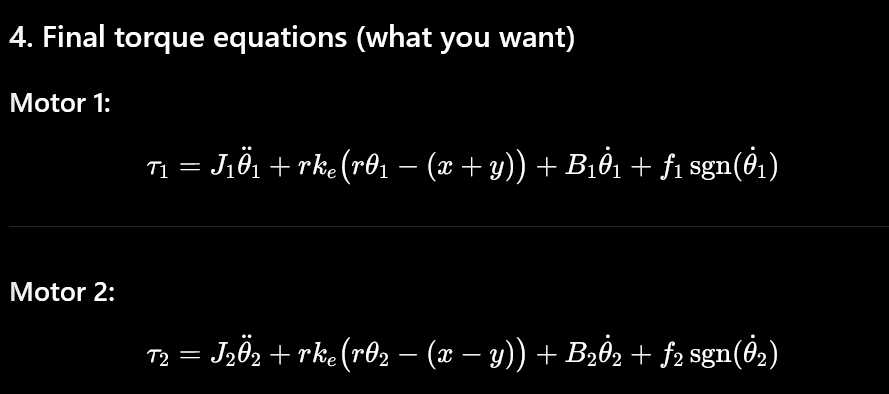

## References
[1] M. Yin, Y. Chen, K. -H. Lee, D. K. C. Fu, Z. T. Ho Tse and K. -W. Kwok, "Dynamic 
Modeling and Characterization of the Core- XyCartesian Motion System," 2018 IEEE International Conference on Real-time Computing and Robotics (RCAR), Kandima, Maldives, 2018, pp. 206-211, doi: 10.1109/RCAR.2018.8621684.
